© 2026 WaLSA Team - Shahin Jafarzadeh et al.

This notebook is part of the [WaLSAlib](https://github.com/WaLSAteam/WaLSAlib) package (v1.0.0), provided under the [Apache License, Version 2.0](http://www.apache.org/licenses/LICENSE-2.0).

You may use, modify, and distribute this notebook and its contents under the terms of the license.

---

**Important Note on Figures**:
Figures generated using this notebook that are **identical to or derivative of those published in**:  
**Jafarzadeh, S., Jess, D. B., Stangalini, M. et al. 2026, *Frontiers in Astronomy and Space Sciences*, in press**,  
as part of the research topic: **[Magnetohydrodynamic Motions: Daniel K. Inouye Solar Telescope’s Window into the Dynamic Sun](https://www.frontiersin.org/research-topics/71781/magnetohydrodynamic-motions-daniel-k-inouye-solar-telescopes-window-into-the-dynamic-sun)**,    
are copyrighted by ***Frontiers in Astronomy and Space Sciences***. Any reuse of such figures requires explicit permission from the journal.   

Figures that are newly created, modified, or unrelated to the published article may be used under the terms of the Apache License.

---

**Disclaimer**:
This notebook and its code are provided "as is", without warranty of any kind, express or implied. Refer to the license for more details.

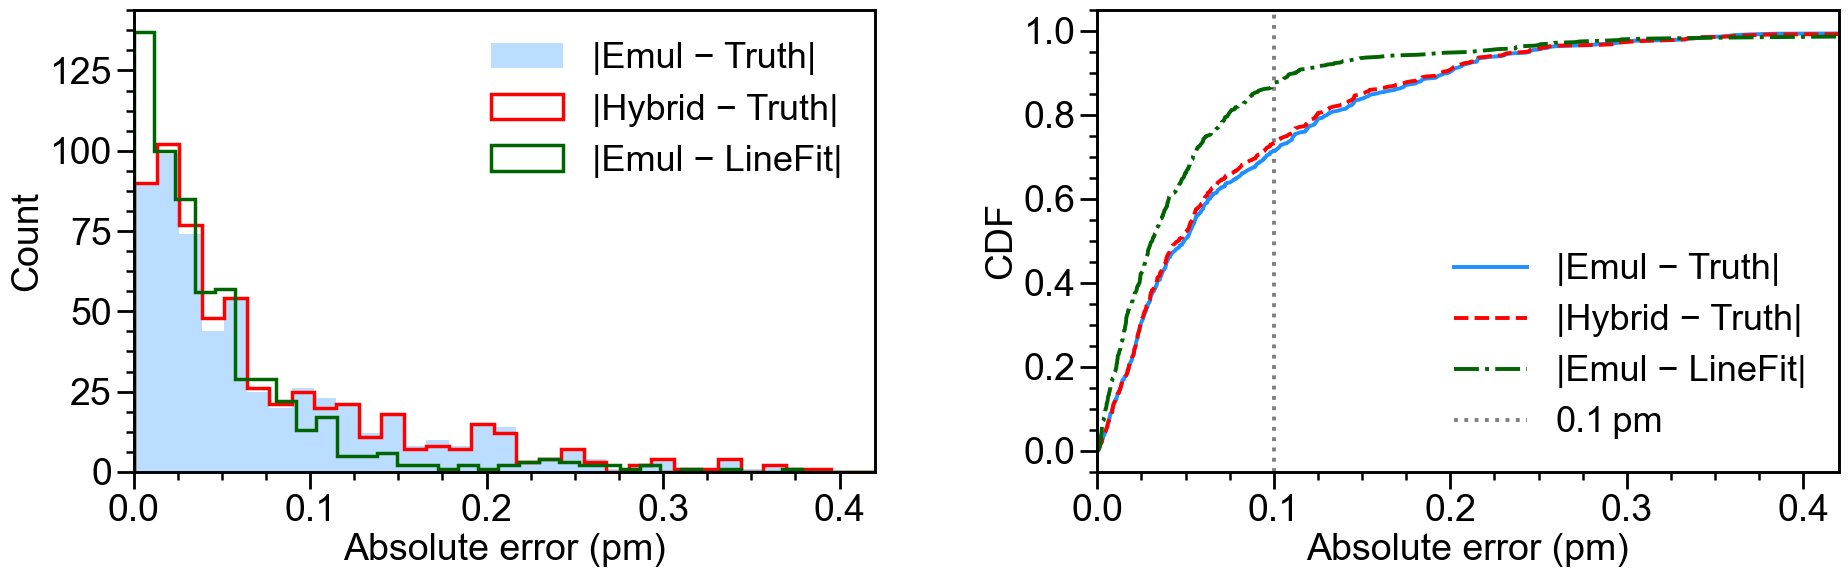

GPL Ghostscript 10.06.0 (2025-09-09)
Copyright (C) 2025 Artifex Software, Inc.  All rights reserved.
This software is supplied under the GNU AGPLv3 and comes with NO WARRANTY:
see the file COPYING for details.
Processing pages 1 through 1.
Page 1
PDF saved in CMYK format as 'Figures/FigureS2_val_error_hist_cdf.pdf'
Saved: Figures/FigureS2_val_error_hist_cdf.pdf
Computing RGWS — please wait (~1 min)...


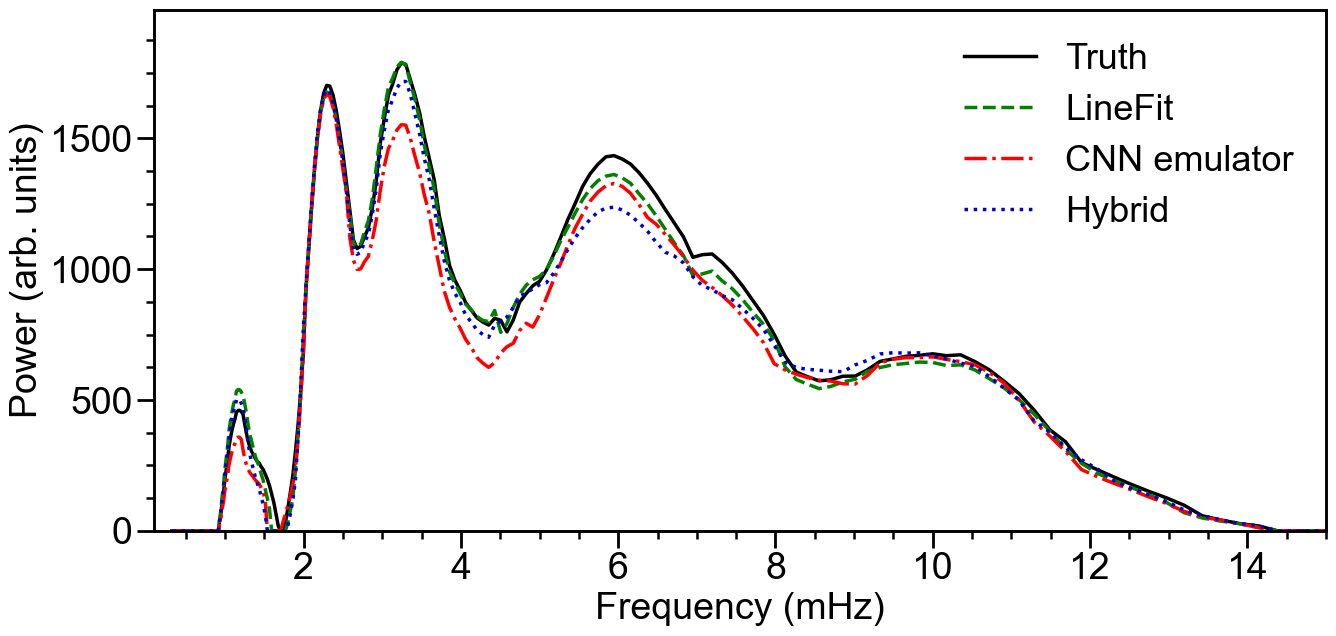

GPL Ghostscript 10.06.0 (2025-09-09)
Copyright (C) 2025 Artifex Software, Inc.  All rights reserved.
This software is supplied under the GNU AGPLv3 and comes with NO WARRANTY:
see the file COPYING for details.
Processing pages 1 through 1.
Page 1
PDF saved in CMYK format as 'Figures/FigureS3_rgws_line6.pdf'
Saved: Figures/FigureS3_rgws_line6.pdf


In [1]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
================================================================================
Produce the two supplementary figures for the PoP emulator section.

Figures produced
----------------
  Figure S2 : Validation error histograms and CDFs
  Figure S3 : RGWS of velocity time series, stress-case line

Inputs required (produced by PoP_CNN_emulator.ipynb)
-----------------------------------------------------------
  Files/PoP_CNN_emulator_outputs/val_diagnostics.npz
  Files/PoP_CNN_emulator_outputs/predictions_line6.npz

Authors
-------
  WaLSA Team / Shahin Jafarzadeh (2026)
  https://WaLSA.team

License
-------
  Apache-2.0 license — see LICENSE file in the WaLSAlib repository.
  https://github.com/WaLSAteam/WaLSAlib

"""

import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
from WaLSAtools import WaLSAtools, WaLSA_detrend_apod, WaLSA_save_pdf  # type: ignore

# =============================================================================
# Configuration
# =============================================================================
OUTDIR = os.path.join("Files", "PoP_CNN_emulator_outputs")

VAL_DIAG_NPZ = os.path.join(OUTDIR, "val_diagnostics.npz")
LINE6_NPZ    = os.path.join(OUTDIR, "predictions_line6.npz")

# Output PDF paths
PDF_FIG_A = "Figures/FigureS2_val_error_hist_cdf.pdf"
PDF_FIG_B = "Figures/FigureS3_rgws_line6.pdf"

# RGWS settings — must match main paper analysis
APOD     = 0.10
SIGLEVEL = 0.95
MOTHER   = "morlet"

# Method styles — consistent with rest of paper
METHOD_STYLES = {
    "Truth":       {"color": "black",      "linestyle": "-"},
    "LineFit":     {"color": "green",      "linestyle": "--"},
    "CNN emulator":{"color": "red",        "linestyle": "-."},
    "Hybrid":      {"color": "mediumblue", "linestyle": ":"},
}

# Histogram/CDF colours
HIST_COLORS = {
    "|Emul - Truth|":   "dodgerblue",
    "|Hybrid - Truth|": "red",
    "|Emul - LineFit|": "darkgreen",
}


# =============================================================================
# Global plot style (matches Figure 5)
# =============================================================================
plt.rcParams.update({
    "font.family":       "sans-serif",
    "font.sans-serif":   "Arial",
    "font.size":         28,
    "axes.titlesize":    27,
    "axes.labelsize":    27,
    "xtick.labelsize":   27,
    "ytick.labelsize":   27,
    "legend.fontsize":   26,
    "figure.titlesize":  28,
    "axes.grid":         False,
    "font.weight":       500,
    "axes.titleweight":  500,
    "axes.labelweight":  500,
})
plt.rc("axes", linewidth=2.1)
plt.rc("lines", linewidth=1.8)


# =============================================================================
# Helper: RGWS
# =============================================================================
def compute_rgws(times_s, v_kms):
    v_apod = WaLSA_detrend_apod(v_kms, apod=APOD, silent=True)
    out = WaLSAtools(
        signal=v_apod, time=times_s, method="wavelet",
        siglevel=SIGLEVEL, apod=APOD, mother=MOTHER,
        GWS=True, RGWS=True,
        cadence=float(np.nanmedian(np.diff(times_s))),
        silent=True, nodetrendapod=True,
    )
    return 1e3 / np.asarray(out[1], float), np.asarray(out[-1], float)


def interp_to_ref(f_src, P_src, f_ref):
    m = np.isfinite(f_src) & np.isfinite(P_src)
    if np.count_nonzero(m) < 2:
        return np.full_like(f_ref, np.nan)
    o = np.argsort(f_src[m])
    return np.interp(f_ref, f_src[m][o], P_src[m][o], left=np.nan, right=np.nan)


def style_ax(ax):
    """Apply standard tick styling matching Figure 5."""
    ax.tick_params(axis="both", which="major", length=12, width=2.0)
    ax.tick_params(axis="both", which="minor", length=6,  width=1.8)
    ax.xaxis.set_minor_locator(AutoMinorLocator(4))
    ax.yaxis.set_minor_locator(AutoMinorLocator(4))


# =============================================================================
# Load data
# =============================================================================
dv = np.load(VAL_DIAG_NPZ)
d6 = np.load(LINE6_NPZ)

err_emul_truth   = dv["err_emul_truth"].astype(float)
err_emul_linefit = dv["err_emul_linefit"].astype(float)
err_hyb_truth    = dv["err_hyb_truth"].astype(float)

time_s    = d6["time_s"].astype(float)
v_truth   = d6["v_truth_kms"].astype(float)
v_linefit = d6["v_linefit_kms"].astype(float)
v_emul    = d6["v_emul_kms"].astype(float)
v_hyb     = d6["v_hybrid_kms"].astype(float)


# =============================================================================
# Figure S2: Validation error histograms and CDFs
# =============================================================================
def cdf(x):
    x = np.sort(x[np.isfinite(x)])
    return x, np.linspace(0.0, 1.0, x.size)

fig_a, axes = plt.subplots(1, 2, figsize=(22, 6), gridspec_kw={"wspace": 0.30})

# --- Histogram ---
ax = axes[0]
ax.hist(np.abs(err_emul_truth),   bins=60, alpha=0.3,
        color=HIST_COLORS["|Emul - Truth|"],   label="|Emul \u2212 Truth|")

n, bins, patches = ax.hist(np.abs(err_hyb_truth), bins=60, histtype='step',
                            color=HIST_COLORS["|Hybrid - Truth|"], label="|Hybrid \u2212 Truth|")
patches[0].set_linewidth(2.5)

n, bins, patches = ax.hist(np.abs(err_emul_linefit), bins=60, histtype='step',
                            color=HIST_COLORS["|Emul - LineFit|"], label="|Emul \u2212 LineFit|")
patches[0].set_linewidth(2.5)

ax.set_xlabel("Absolute error (pm)")
ax.set_ylabel("Count")
ax.legend(frameon=False)
ax.set_xlim(0.0, 0.42)
style_ax(ax)

# --- CDF ---
ax = axes[1]
x1, y1 = cdf(np.abs(err_emul_truth))
x2, y2 = cdf(np.abs(err_hyb_truth))
x3, y3 = cdf(np.abs(err_emul_linefit))
ax.plot(x1, y1, "-",  color=HIST_COLORS["|Emul - Truth|"],   lw=2.8, label="|Emul \u2212 Truth|")
ax.plot(x2, y2, "--", color=HIST_COLORS["|Hybrid - Truth|"], lw=2.8, label="|Hybrid \u2212 Truth|")
ax.plot(x3, y3, "-.", color=HIST_COLORS["|Emul - LineFit|"], lw=2.8, label="|Emul \u2212 LineFit|")
ax.axvline(0.1, color="gray", lw=2.8, ls=":", label="0.1\u2009pm", zorder=-10)
ax.set_xlabel("Absolute error (pm)")
ax.set_ylabel("CDF")
ax.legend(frameon=False)
ax.set_xlim(0.0, 0.42)
style_ax(ax)

# fig_a.tight_layout()
plt.show()
WaLSA_save_pdf(fig_a, PDF_FIG_A, color_mode="CMYK", dpi=300, bbox_inches="tight", pad_inches=0.1)
print(f"Saved: {PDF_FIG_A}")


# =============================================================================
# Figure S3: RGWS of velocity time series
# =============================================================================
print("Computing RGWS — please wait (~1 min)...")

fT, PT = compute_rgws(time_s, v_truth)
fL, PL = compute_rgws(time_s, v_linefit)
fE, PE = compute_rgws(time_s, v_emul)
fH, PH = compute_rgws(time_s, v_hyb)

PLi = interp_to_ref(fL, PL, fT)
PEi = interp_to_ref(fE, PE, fT)
PHi = interp_to_ref(fH, PH, fT)

fig_b, ax = plt.subplots(figsize=(14, 7))

for label, f_arr, P_arr in [
    ("Truth",        fT, PT),
    ("LineFit",      fT, PLi),
    ("CNN emulator", fT, PEi),
    ("Hybrid",       fT, PHi),
]:
    st = METHOD_STYLES[label]
    ax.plot(f_arr, P_arr,
            color=st["color"], linestyle=st["linestyle"],
            lw=2.5, label=label)

ax.set_xlim(0.1, 15.0)
ax.set_ylim(0, 1.99e3)
ax.set_xlabel("Frequency (mHz)")
ax.set_ylabel("Power (arb. units)")
ax.legend(frameon=False)
style_ax(ax)

fig_b.tight_layout()
plt.show()
WaLSA_save_pdf(fig_b, PDF_FIG_B, color_mode="CMYK", dpi=300, bbox_inches="tight", pad_inches=0.1)
print(f"Saved: {PDF_FIG_B}")